# Recrutement et transition écologique en France (2023)

## Contexte
La transition écologique implique une transformation profonde du marché du travail. 
Ce notebook analyse les données de l'enquête Besoins en Main d'Oeuvre (BMO) 2023 
de France Travail pour mesurer le poids des métiers verts dans les recrutements 
et identifier les tensions sur ce segment du marché du travail.

## Source des données
Enquête BMO 2023 — France Travail / DARES  
Disponible sur : https://www.data.gouv.fr/datasets/enquete-besoins-en-main-doeuvre-bmo

## Structure de l'analyse
1. Chargement et nettoyage des données
2. Identification des métiers verts
3. Poids des métiers verts dans les recrutements
4. Volume de recrutement et tensions par métier vert
5. Comparaison métiers verts vs non-verts
6. Disparités régionales
7. Focus sur les métiers les plus en tension

## 1. Chargement et nettoyage des données
Chargement du fichier BMO 2023 et conversion des variables numériques. 
Les valeurs non numériques (ex: * pour données masquées) sont converties en NaN.

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importation données DARES
chemin = r"C:\Users\Clément FAYS\OneDrive - Agence universitaire de la Francophonie\Bureau\Divers\Python\Formation\BMO\Donnees_consolidees_2023\Base_open_data_23.xlsx"

xl = pd.ExcelFile(chemin)
print("Onglets disponibles :", xl.sheet_names)

Onglets disponibles : ['Description des variables', 'BMO_2023_open_data']


In [104]:

df = pd.read_excel(chemin, sheet_name="BMO_2023_open_data")

# Premier aperçu
print(f"Dimensions : {df.shape}")
print("\nColonnes :")
print(df.columns.tolist())
df.head(10)

Dimensions : (50437, 14)

Colonnes :
['annee', 'Code métier BMO', 'Nom métier BMO', 'Famille_met', 'Lbl_fam_met', 'BE23', 'NOMBE23', 'Dept', 'NomDept', 'REG', 'NOM_REG', 'met', 'xmet', 'smet']


,annee,Code métier BMO,Nom métier BMO,Famille_met,Lbl_fam_met,BE23,NOMBE23,Dept,NomDept,REG,NOM_REG,met,xmet,smet
0,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,101,BASSIN BASSE-TERRE,971,Guadeloupe,1,Guadeloupe,250,58,47
1,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,102,BASSIN GRANDE-TERRE,971,Guadeloupe,1,Guadeloupe,174,114,132
2,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,103,BASSIN MARIE-GALANTE,971,Guadeloupe,1,Guadeloupe,*,*,*
3,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,104,BASSIN ILES DU NORD,971,Guadeloupe,1,Guadeloupe,32,*,16
4,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,105,BASSIN CENTRE,971,Guadeloupe,1,Guadeloupe,65,50,*
5,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,201,MARTINIQUE CENTRE,972,Martinique,2,Martinique,253,145,72
6,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,202,MARTINIQUE NORD ATLANTIQUE,972,Martinique,2,Martinique,236,155,33
7,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,203,MARTINIQUE SUD,972,Martinique,2,Martinique,203,137,150
8,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,204,MARTINIQUE NORD CARAIBE,972,Martinique,2,Martinique,53,43,22
9,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,302,SAINT LAURENT DU MARONI,973,Guyane,3,Guyane,44,17,30


In [76]:
# Dimensions
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

# Noms des colonnes
print("Colonnes disponible :")
for col in df.columns:
    print(f"  - {col}")

Dimensions : 50437 lignes x 14 colonnes
Colonnes disponible :
  - annee
  - Code métier BMO
  - Nom métier BMO
  - Famille_met
  - Lbl_fam_met
  - BE23
  - NOMBE23
  - Dept
  - NomDept
  - REG
  - NOM_REG
  - met
  - xmet
  - smet


In [77]:
# Aperçu des premières lignes
df.head(10)

,annee,Code métier BMO,Nom métier BMO,Famille_met,Lbl_fam_met,BE23,NOMBE23,Dept,NomDept,REG,NOM_REG,met,xmet,smet
0,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,101,BASSIN BASSE-TERRE,971,Guadeloupe,1,Guadeloupe,250,58,47
1,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,102,BASSIN GRANDE-TERRE,971,Guadeloupe,1,Guadeloupe,174,114,132
2,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,103,BASSIN MARIE-GALANTE,971,Guadeloupe,1,Guadeloupe,*,*,*
3,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,104,BASSIN ILES DU NORD,971,Guadeloupe,1,Guadeloupe,32,*,16
4,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,105,BASSIN CENTRE,971,Guadeloupe,1,Guadeloupe,65,50,*
5,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,201,MARTINIQUE CENTRE,972,Martinique,2,Martinique,253,145,72
6,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,202,MARTINIQUE NORD ATLANTIQUE,972,Martinique,2,Martinique,236,155,33
7,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,203,MARTINIQUE SUD,972,Martinique,2,Martinique,203,137,150
8,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,204,MARTINIQUE NORD CARAIBE,972,Martinique,2,Martinique,53,43,22
9,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,302,SAINT LAURENT DU MARONI,973,Guyane,3,Guyane,44,17,30


In [78]:
# Types de variables et valeurs manquantes
print("Types de variables :")
print(df.dtypes)
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Types de variables :
annee               int64
Code métier BMO    object
Nom métier BMO     object
Famille_met        object
Lbl_fam_met        object
BE23                int64
NOMBE23            object
Dept               object
NomDept            object
REG                 int64
NOM_REG            object
met                object
xmet               object
smet               object
dtype: object
Valeurs manquantes par colonne :
annee              0
Code métier BMO    0
Nom métier BMO     0
Famille_met        0
Lbl_fam_met        0
BE23               0
NOMBE23            0
Dept               0
NomDept            0
REG                0
NOM_REG            0
met                0
xmet               0
smet               0
dtype: int64


In [79]:
# Voir les valeurs uniques de la colonne métier (adapte le nom de colonne)
print(df.columns.tolist())

# Combien de métiers distincts ?
print(f"\nNombre de lignes : {len(df)}")

# Aperçu des 20 premières valeurs de chaque colonne
df.head(20)

['annee', 'Code métier BMO', 'Nom métier BMO', 'Famille_met', 'Lbl_fam_met', 'BE23', 'NOMBE23', 'Dept', 'NomDept', 'REG', 'NOM_REG', 'met', 'xmet', 'smet']

Nombre de lignes : 50437


,annee,Code métier BMO,Nom métier BMO,Famille_met,Lbl_fam_met,BE23,NOMBE23,Dept,NomDept,REG,NOM_REG,met,xmet,smet
0,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,101,BASSIN BASSE-TERRE,971,Guadeloupe,1,Guadeloupe,250,58,47
1,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,102,BASSIN GRANDE-TERRE,971,Guadeloupe,1,Guadeloupe,174,114,132
2,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,103,BASSIN MARIE-GALANTE,971,Guadeloupe,1,Guadeloupe,*,*,*
3,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,104,BASSIN ILES DU NORD,971,Guadeloupe,1,Guadeloupe,32,*,16
4,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,105,BASSIN CENTRE,971,Guadeloupe,1,Guadeloupe,65,50,*
5,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,201,MARTINIQUE CENTRE,972,Martinique,2,Martinique,253,145,72
6,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,202,MARTINIQUE NORD ATLANTIQUE,972,Martinique,2,Martinique,236,155,33
7,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,203,MARTINIQUE SUD,972,Martinique,2,Martinique,203,137,150
8,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,204,MARTINIQUE NORD CARAIBE,972,Martinique,2,Martinique,53,43,22
9,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,302,SAINT LAURENT DU MARONI,973,Guyane,3,Guyane,44,17,30


In [80]:
# Liste de tous les métiers uniques
metiers = df["Nom métier BMO"].unique()
print(f"Nombre de métiers distincts : {len(metiers)}")
print("\nListe complète :")
for m in sorted(metiers):
    print(f"  - {m}")

Nombre de métiers distincts : 199

Liste complète :
  - Agents administratifs des transports
  - Agents administratifs divers
  - Agents d'accueil et d'information
  - Agents d'entretien de locaux
  - Agents d'exploitation des transports
  - Agents de maîtrise en entretien
  - Agents de maîtrise et assimilés des industries de process
  - Agents de maîtrise et assimilés en fabrication de matériel électrique, électronique
  - Agents de maîtrise et assimilés en fabrication mécanique
  - Agents de services hospitaliers
  - Agents de sécurité et de surveillance
  - Agents et hôtesses d'accompagnement
  - Agents immobiliers, syndics
  - Agents qualifiés de laboratoire
  - Agents qualifiés de traitement thermique et de surface
  - Agriculteurs salariés
  - Aides de cuisine, apprentis de cuisine et employés polyvalents de la restauration
  - Aides à domicile et aides ménagères
  - Aides-soignants
  - Apprentis et ouvriers non qualifiés de l'alimentation (hors industries agro-alimentaires)
  - 

## 2. Identification des métiers verts
Nous identifions 18 métiers liés à la transition écologique sur la base 
de leurs intitulés. Cette catégorisation manuelle distingue deux groupes :
les métiers **clairement verts** (agriculture, environnement, forêt...) 
et les métiers **contribuant à la transition** (bâtiment, énergie...).

In [81]:
metiers_verts = [
    # Clairement verts
    "Bûcherons, sylviculteurs salariés et agents forestiers",
    "Conducteurs d'engins agricoles ou forestiers",
    "Ouvriers de l'assainissement et du traitement des déchets",
    "Techniciens et agents de maîtrise de la maintenance et de l'environnement",
    "Cadres techniques de la maintenance et de l'environnement",
    "Ingénieurs, cadres techniques de l'agriculture",
    "Agriculteurs salariés",
    "Maraîchers, horticulteurs salariés",
    "Viticulteurs, arboriculteurs salariés",
    "Éleveurs salariés",
    "Pêcheurs, aquaculteurs salariés",
    "Jardiniers salariés",
    "Techniciens et agents d'encadrement d'exploitations agricoles",
    # Probablement verts
    "Plombiers, chauffagistes",
    "Électriciens du bâtiment",
    "Menuisiers et ouvriers de l'agencement et de l'isolation",
    "Ouvriers qualifiés des travaux publics, du béton et de l'extraction",
    "Autres ouvriers qualifiés en verre, céramique, métallurgie, matériaux de construction et énergie"
]

# Création de la colonne flag
df["metier_vert"] = df["Nom métier BMO"].isin(metiers_verts).astype(int)

# Vérification
n_verts = df[df["metier_vert"] == 1]["Nom métier BMO"].nunique()
print(f"Nombre de métiers verts identifiés : {n_verts}")
print(f"Nombre de lignes concernées : {df['metier_vert'].sum()}")

Nombre de métiers verts identifiés : 17
Nombre de lignes concernées : 5108


In [82]:
# Vérifier lesquels n'ont pas été reconnus
for metier in metiers_verts:
    if metier not in df["Nom métier BMO"].values:
        print(f"NON RECONNU : '{metier}'")

NON RECONNU : 'Autres ouvriers qualifiés en verre, céramique, métallurgie, matériaux de construction et énergie'


In [83]:
nom_exact = [m for m in df["Nom métier BMO"].values if "verre" in m.lower()]
print(nom_exact)

['Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en métallurgie, verre, céramique et matériaux de construction', 'Ouvriers non qualifiés en méta

In [84]:
# Nettoyer les espaces insécables dans toute la colonne
df["Nom métier BMO"] = df["Nom métier BMO"].str.replace("\xa0", " ").str.strip()

# Relancer la création du flag
df["metier_vert"] = df["Nom métier BMO"].isin(metiers_verts).astype(int)

# Vérification
n_verts = df[df["metier_vert"] == 1]["Nom métier BMO"].nunique()
print(f"Nombre de métiers verts identifiés : {n_verts}")
print(f"Nombre de lignes concernées : {df['metier_vert'].sum()}")

Nombre de métiers verts identifiés : 18
Nombre de lignes concernées : 5234


In [85]:
# Convertir met et xmet en numérique (les * et autres caractères deviennent NaN)
df["met"] = pd.to_numeric(df["met"], errors="coerce")
df["xmet"] = pd.to_numeric(df["xmet"], errors="coerce")
df["smet"] = pd.to_numeric(df["smet"], errors="coerce")

# Vérification
print(f"Type de 'met' : {df['met'].dtype}")
print(f"Valeurs manquantes dans 'met' : {df['met'].isna().sum()}")

Type de 'met' : float64
Valeurs manquantes dans 'met' : 9196


## 3. Poids des métiers verts
Les métiers verts représentent **14,3% des projets de recrutement** en France 
en 2023, soit 429 748 projets sur 3 013 134 au total

In [86]:
# Agréger au niveau national
total_recrutements = df["met"].sum()
recrutements_verts = df[df["metier_vert"] == 1]["met"].sum()
part_verts = (recrutements_verts / total_recrutements * 100).round(1)

print(f"Total projets de recrutement (France) : {total_recrutements:,}")
print(f"Dont métiers verts : {recrutements_verts:,}")
print(f"Part des métiers verts : {part_verts}%")

Total projets de recrutement (France) : 3,013,134.0
Dont métiers verts : 429,748.0
Part des métiers verts : 14.3%


In [87]:
df_verts = df[df["metier_vert"] == 1 ].groupby("Nom métier BMO").agg(recrutements=("met","sum"),recrutements_difficiles=("xmet","sum")).reset_index()
df_verts.head(10)

,Nom métier BMO,recrutements,recrutements_difficiles
0,Agriculteurs salariés,91912.0,54928.0
1,"Autres ouvriers qualifiés en verre, céramique,...",1814.0,1165.0
2,"Bûcherons, sylviculteurs salariés et agents fo...",4702.0,3215.0
3,Cadres techniques de la maintenance et de l'en...,3646.0,2061.0
4,Conducteurs d'engins agricoles ou forestiers,7716.0,4716.0
5,"Ingénieurs, cadres techniques de l'agriculture",796.0,392.0
6,Jardiniers salariés,34637.0,17378.0
7,"Maraîchers, horticulteurs salariés",25651.0,15431.0
8,Menuisiers et ouvriers de l'agencement et de l...,17848.0,14016.0
9,Ouvriers de l'assainissement et du traitement ...,14776.0,6180.0


## 4. Volume et tensions par métier vert
Analyse du volume de recrutement et du taux de difficulté pour chacun 
des 18 métiers verts identifiés.

In [88]:
# Calculer le taux de difficulté
df_verts["taux_difficile"] = ((df_verts["recrutements_difficiles"]/df_verts["recrutements"])*100).round(1)

#Trier par volume de recrutement
df_verts = df_verts.sort_values("recrutements", ascending=False)
df_verts

,Nom métier BMO,recrutements,recrutements_difficiles,taux_difficile
15,"Viticulteurs, arboriculteurs salariés",121036.0,65305.0,54.0
0,Agriculteurs salariés,91912.0,54928.0,59.8
6,Jardiniers salariés,34637.0,17378.0,50.2
14,Techniciens et agents de maîtrise de la mainte...,29813.0,21318.0,71.5
7,"Maraîchers, horticulteurs salariés",25651.0,15431.0,60.2
11,"Plombiers, chauffagistes",22049.0,17866.0,81.0
8,Menuisiers et ouvriers de l'agencement et de l...,17848.0,14016.0,78.5
16,Électriciens du bâtiment,17596.0,12868.0,73.1
10,"Ouvriers qualifiés des travaux publics, du bét...",16042.0,11493.0,71.6
9,Ouvriers de l'assainissement et du traitement ...,14776.0,6180.0,41.8


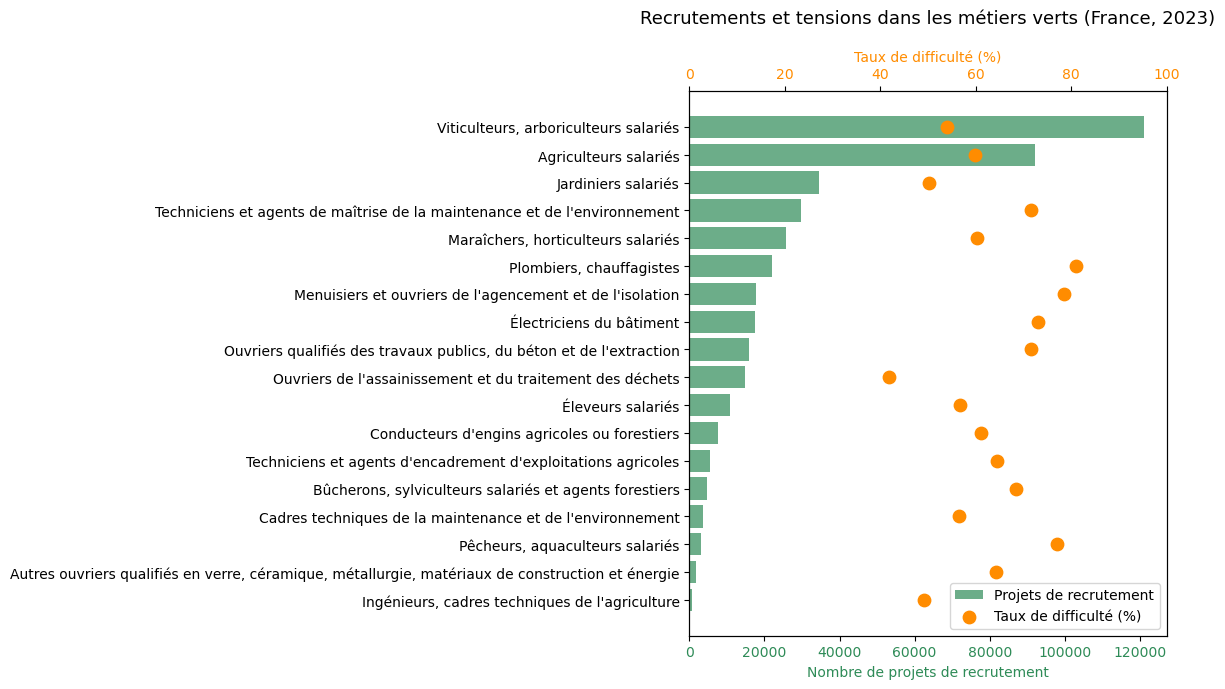

In [89]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Axe 1 : barres horizontales pour le volume ---
ax1.barh(
    df_verts["Nom métier BMO"],
    df_verts["recrutements"],
    color="seagreen",
    alpha=0.7,
    label="Projets de recrutement"
)
ax1.set_xlabel("Nombre de projets de recrutement", color="seagreen")
ax1.tick_params(axis="x", labelcolor="seagreen")
ax1.invert_yaxis()

# --- Axe 2 : scatter pour le taux de difficulté ---
ax2 = ax1.twiny()  # crée un deuxième axe x en haut
ax2.scatter(
    df_verts["taux_difficile"],
    df_verts["Nom métier BMO"],
    color="darkorange",
    zorder=5,
    s=80,
    label="Taux de difficulté (%)"
)
ax2.set_xlabel("Taux de difficulté (%)", color="darkorange")
ax2.set_xlim(0, 100)
ax2.tick_params(axis="x", labelcolor="darkorange")

# --- Légende et titre ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.title("Recrutements et tensions dans les métiers verts (France, 2023)", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## 5. Comparaison métiers verts vs non-verts
Le taux de difficulté de recrutement est quasi-identique entre métiers verts 
(60,6%) et non-verts (60,8%). Les métiers verts ne semblent pas faire face 
à des tensions structurellement plus fortes que le reste du marché du travail.

In [90]:
# Calculer le taux de difficulté moyen pour chaque groupe
comparaison = df.groupby("metier_vert").agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

comparaison["taux_difficulte"] = (
    comparaison["recrutements_difficiles"] / comparaison["recrutements"] * 100
).round(1)

# Rendre les labels lisibles
comparaison["groupe"] = comparaison["metier_vert"].map({0: "Métiers non verts", 1: "Métiers verts"})

print(comparaison[["groupe", "recrutements", "recrutements_difficiles", "taux_difficulte"]])

              groupe  recrutements  recrutements_difficiles  taux_difficulte
0  Métiers non verts     2583386.0                1569864.0             60.8
1      Métiers verts      429748.0                 260606.0             60.6


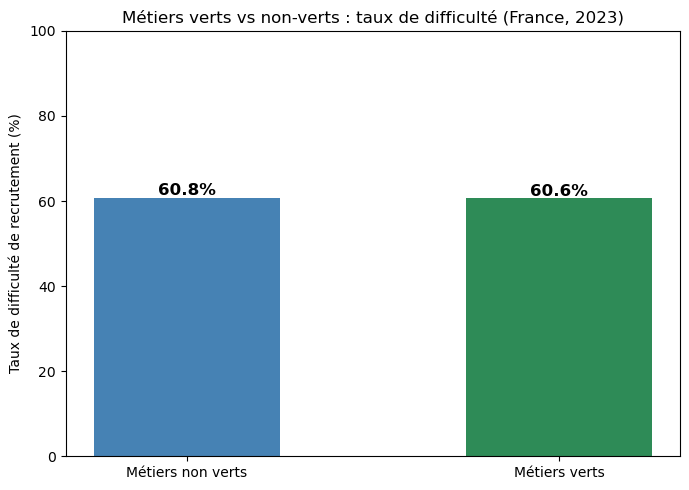

In [91]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ["steelblue", "seagreen"]
bars = ax.bar(
    comparaison["groupe"],
    comparaison["taux_difficulte"],
    color=colors,
    width=0.5
)

# Ajouter les valeurs au dessus des barres
for bar, val in zip(bars, comparaison["taux_difficulte"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylim(0, 100)
ax.set_ylabel("Taux de difficulté de recrutement (%)")
ax.set_title("Métiers verts vs non-verts : taux de difficulté (France, 2023)", fontsize=12)

plt.tight_layout()
plt.show()

"Contrairement à ce qu'on pourrait attendre, les métiers verts ne présentent pas de taux de difficulté significativement plus élevé que les autres métiers (60,6% vs 60,8%). Ce résultat agrégé masque toutefois des disparités importantes entre métiers, analysées en section 2."

## 6. Disparités régionales
Analyse des recrutements verts et des tensions par région. 
Les disparités régionales restent limitées au niveau agrégé.

In [92]:
# Agréger par région, uniquement pour les métiers verts
df_regions = df[df["metier_vert"] == 1].groupby("NOM_REG").agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

# Taux de difficulté par région
df_regions["taux_difficulte"] = (
    df_regions["recrutements_difficiles"] / df_regions["recrutements"] * 100
).round(1)

# Trier par volume
df_regions = df_regions.sort_values("recrutements", ascending=False)
print(df_regions)

                       NOM_REG  recrutements  recrutements_difficiles  \
13          Nouvelle-Aquitaine       70551.0                  49748.0   
14                   Occitanie       48662.0                  25820.0   
0         Auvergne-Rhône-Alpes       47580.0                  27329.0   
5                    Grand Est       41303.0                  21511.0   
16  Provence-Alpes-Côte d'Azur       37214.0                  23789.0   
15            Pays de la Loire       34371.0                  22254.0   
17               Île-de-France       32076.0                  19403.0   
8              Hauts-de-France       27447.0                  13643.0   
1      Bourgogne-Franche-Comté       21952.0                  12098.0   
2                     Bretagne       20294.0                  13576.0   
3          Centre-Val de Loire       16844.0                  12227.0   
12                   Normandie       15451.0                  11044.0   
9                   La Réunion        5998.0       

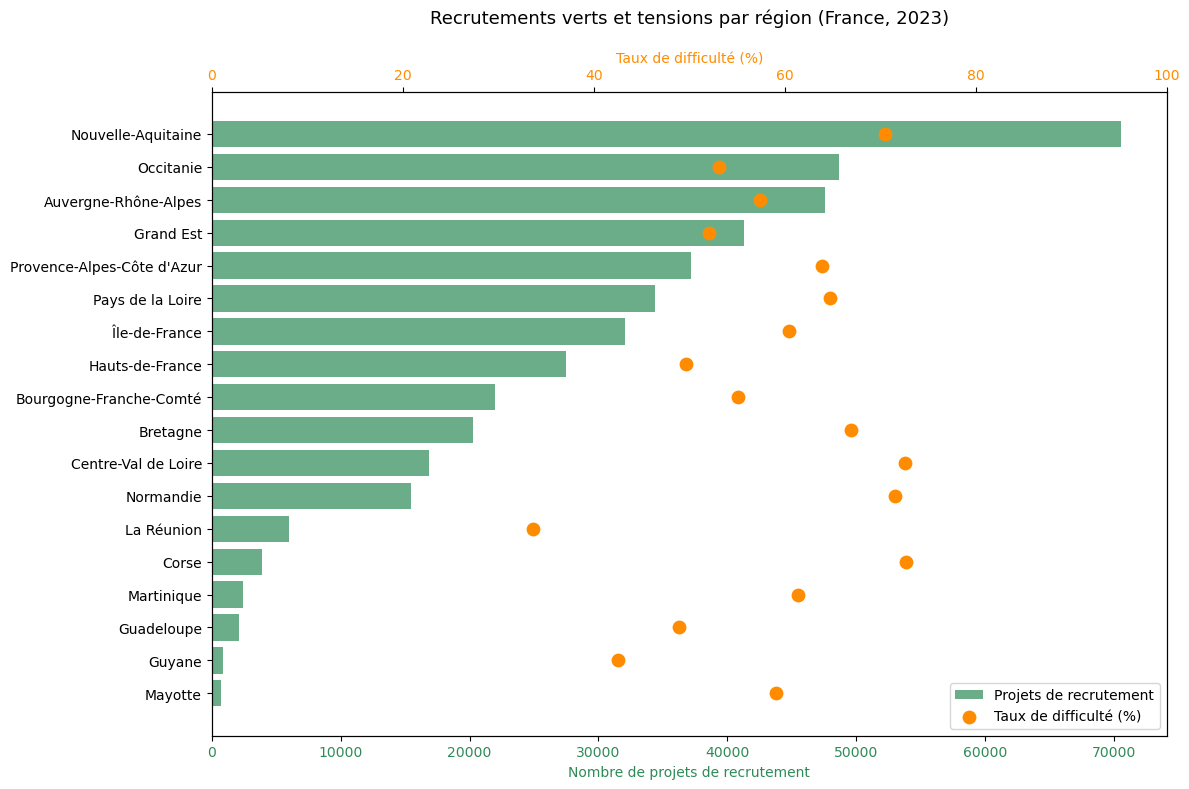

In [93]:
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.barh(
    df_regions["NOM_REG"],
    df_regions["recrutements"],
    color="seagreen",
    alpha=0.7,
    label="Projets de recrutement"
)
ax1.set_xlabel("Nombre de projets de recrutement", color="seagreen")
ax1.tick_params(axis="x", labelcolor="seagreen")
ax1.invert_yaxis()

ax2 = ax1.twiny()
ax2.scatter(
    df_regions["taux_difficulte"],
    df_regions["NOM_REG"],
    color="darkorange",
    zorder=5,
    s=80,
    label="Taux de difficulté (%)"
)
ax2.set_xlabel("Taux de difficulté (%)", color="darkorange")
ax2.tick_params(axis="x", labelcolor="darkorange")
ax2.set_xlim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.title("Recrutements verts et tensions par région (France, 2023)", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [94]:
# Agréger par région ET métier
df_reg_met = df[df["metier_vert"] == 1].groupby(
    ["NOM_REG", "Nom métier BMO"]
).agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

df_reg_met["taux_difficulte"] = (
    df_reg_met["recrutements_difficiles"] / df_reg_met["recrutements"] * 100
).round(1)

# Top 15 des combinaisons région/métier les plus en tension
# avec un minimum de recrutements pour éviter les cas marginaux
top_tensions = df_reg_met[df_reg_met["recrutements"] >= 500]\
    .sort_values("taux_difficulte", ascending=False)\
    .head(15)

print(top_tensions[["NOM_REG", "Nom métier BMO", "recrutements", "taux_difficulte"]])

                     NOM_REG  \
63       Centre-Val de Loire   
233       Nouvelle-Aquitaine   
28   Bourgogne-Franche-Comté   
215                Normandie   
11      Auvergne-Rhône-Alpes   
219                Normandie   
268         Pays de la Loire   
232       Nouvelle-Aquitaine   
60       Centre-Val de Loire   
267         Pays de la Loire   
271         Pays de la Loire   
273         Pays de la Loire   
217                Normandie   
97                 Grand Est   
213                Normandie   

                                        Nom métier BMO  recrutements  \
63                            Plombiers, chauffagistes         809.0   
233                    Pêcheurs, aquaculteurs salariés        1007.0   
28                            Plombiers, chauffagistes         663.0   
215                    Pêcheurs, aquaculteurs salariés         533.0   
11                            Plombiers, chauffagistes        2729.0   
219                           Électriciens du bâtiment 

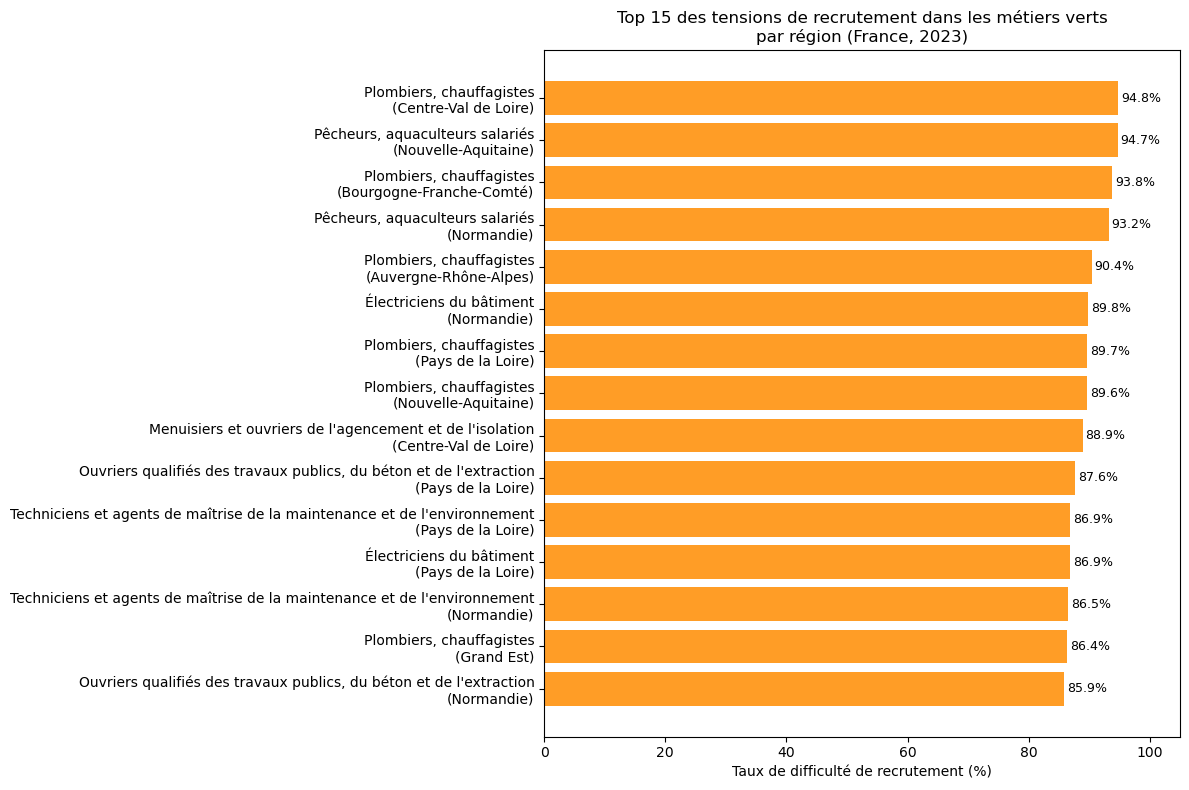

In [95]:
# Créer un label combiné région + métier
top_tensions["label"] = top_tensions["Nom métier BMO"] + "\n(" + top_tensions["NOM_REG"] + ")"

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_tensions["label"],
    top_tensions["taux_difficulte"],
    color="darkorange",
    alpha=0.85
)

# Ajouter les valeurs au bout des barres
for bar, val in zip(bars, top_tensions["taux_difficulte"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val}%",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 105)
ax.set_xlabel("Taux de difficulté de recrutement (%)")
ax.set_title(
    "Top 15 des tensions de recrutement dans les métiers verts\npar région (France, 2023)",
    fontsize=12
)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Focus sur les métiers les plus en tension
Identification des métiers verts présentant les taux de difficulté 
les plus élevés (seuil minimum : 500 projets de recrutement).

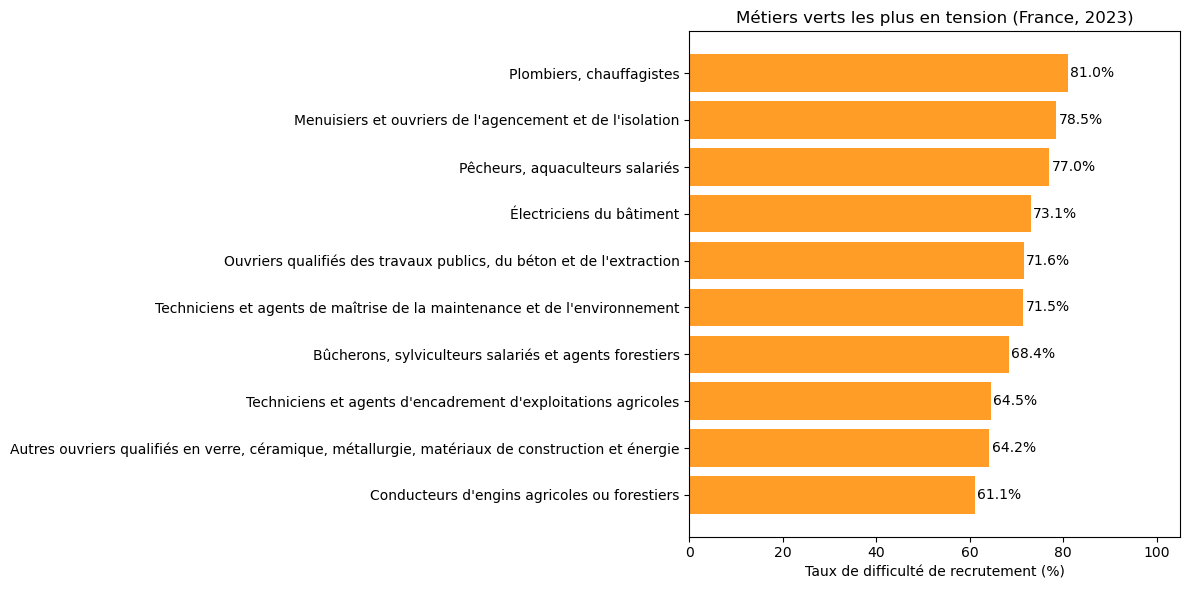

In [96]:
# Top 10 des métiers verts par taux de difficulté
# avec seuil minimum de recrutements
top_metiers = df_verts[df_verts["recrutements"] >= 500]\
    .sort_values("taux_difficile", ascending=False)\
    .head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_metiers["Nom métier BMO"],
    top_metiers["taux_difficile"],
    color="darkorange",
    alpha=0.85
)

for bar, val in zip(bars, top_metiers["taux_difficile"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val}%",
        va="center",
        fontsize=10
    )

ax.set_xlim(0, 105)
ax.set_xlabel("Taux de difficulté de recrutement (%)")
ax.set_title("Métiers verts les plus en tension (France, 2023)", fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Conclusions

L'analyse des données BMO 2023 permet de tirer trois enseignements principaux :

1. **Les métiers verts représentent une part significative du marché du travail** 
(14,3% des recrutements), confirmant le poids croissant de la transition 
écologique dans l'économie française.

2. **Les tensions de recrutement sont hétérogènes** : si le taux de difficulté 
moyen des métiers verts est comparable au reste du marché, certains métiers 
spécifiques présentent des taux supérieurs à 80%, signalant des besoins 
en formation ciblés.

3. **Les disparités régionales restent limitées** au niveau agrégé, suggérant 
que les tensions identifiées sont davantage liées aux caractéristiques 
intrinsèques des métiers qu'à des dynamiques territoriales spécifiques.

### Perspectives
Une analyse longitudinale sur plusieurs années (2019-2023) permettrait 
d'évaluer si ces tensions s'accentuent avec la montée en puissance 
des politiques de transition écologique.